## Figure — z-score et règles de trading

Z-score glissant du spread ADI/MPWR (fenêtre = demi-vie $\approx 43$ j) avec les seuils d'entrée ($\pm2{,}5$), de sortie ($\pm0{,}5$) et de stop-loss ($\pm3{,}0$). Les marqueurs montrent comment le franchissement d'un seuil déclenche une décision.

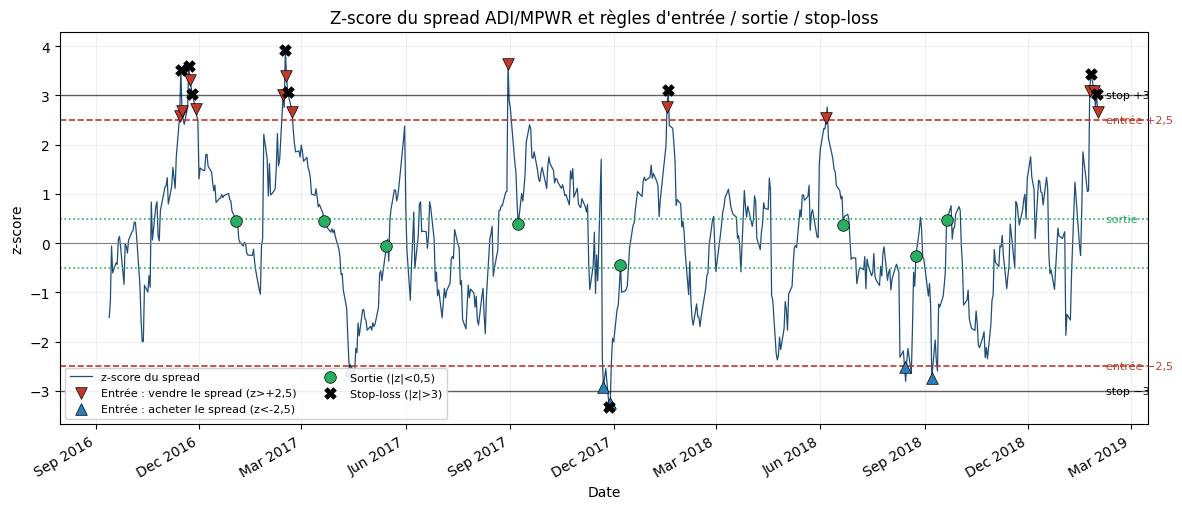

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates

adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)

beta   = 0.256
win_z  = 43            # fenetre = demi-vie
z_in, z_out, z_stop = 2.5, 0.5, 3.0

S = (adj["ADI"] - beta*adj["MPWR"]).dropna()
z = ((S - S.rolling(win_z).mean()) / S.rolling(win_z).std()).dropna()

# --- fenetre de zoom : ~600 jours contenant le plus d'entrees (lisibilite) ---
W = 600
cross = (z.abs() >= z_in).astype(int).rolling(W).sum()
end = cross.idxmax(); p_end = z.index.get_loc(end)
p_start = max(0, p_end - W); zz = z.iloc[p_start:p_end+1]

# --- machine a etats : place entrees / sorties / stops ---
pos = 0; entries_s=[]; entries_l=[]; exits=[]; stops=[]
for d, v in zz.items():
    if pos == 0:
        if v >= z_in:   pos=-1; entries_s.append((d,v))   # vendre le spread
        elif v <= -z_in:pos=+1; entries_l.append((d,v))   # acheter le spread
    else:
        if abs(v) >= z_stop:      pos=0; stops.append((d,v))
        elif abs(v) <= z_out:     pos=0; exits.append((d,v))

fig, ax = plt.subplots(figsize=(12,5.2))
ax.plot(zz.index, zz.values, lw=.9, color="#1f4e79", label="z-score du spread", zorder=2)
ax.axhline(0, color="grey", lw=.8)
for s in (z_in,-z_in):   ax.axhline(s, color="#c0392b", ls="--", lw=1.2)
for s in (z_out,-z_out): ax.axhline(s, color="#27ae60", ls=":",  lw=1.2)
for s in (z_stop,-z_stop):ax.axhline(s, color="black", ls="-",  lw=1.0, alpha=.6)

def scat(pts, m, c, lab):
    if pts: ax.scatter([d for d,_ in pts],[v for _,v in pts], marker=m, s=70,
                        color=c, edgecolor="k", linewidth=.5, zorder=5, label=lab)
scat(entries_s,"v","#c0392b","Entrée : vendre le spread (z>+2,5)")
scat(entries_l,"^","#2980b9","Entrée : acheter le spread (z<-2,5)")
scat(exits,"o","#27ae60","Sortie (|z|<0,5)")
scat(stops,"X","black","Stop-loss (|z|>3)")

# etiquettes des bandes a droite
xr = zz.index[-1]
for y,txt,col in [(z_in,"entrée +2,5","#c0392b"),(-z_in,"entrée −2,5","#c0392b"),
                  (z_out,"sortie","#27ae60"),(z_stop,"stop +3","black"),(-z_stop,"stop −3","black")]:
    ax.text(xr, y, "  "+txt, va="center", fontsize=8, color=col)

ax.set_ylabel("z-score"); ax.set_xlabel("Date")
ax.set_title("Z-score du spread ADI/MPWR et règles d'entrée / sortie / stop-loss")
ax.legend(loc="lower left", fontsize=8, ncol=2, framealpha=.9)
ax.grid(alpha=.2); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig("fig_zscore_regles.png", dpi=150); plt.show()